# Notebook 1: Building the graph

I had temporal lobe epilepsy, controlled since a partial hippocampectomy in [year]. One of the side effects of going through that — years of appointments, EEGs, reading my own notes, asking questions I actually wanted answered — is a fairly solid working knowledge of neuroanatomy. Not clinical expertise. I'm not a neurologist and I'm not trying to sound like one here. But I know my way around brain structure and function well enough that I can lay out the twelve cranial nerves, their brainstem nuclei, and their targets from memory, and be confident I'm not making it up.

That's the starting point for this notebook: encode that knowledge as a graph, and then — in later notebooks — see what formal graph theory says about a structure I already understand informally.

## Scoping the graph

Three layers of nodes:

- **Nerves** — the twelve cranial nerves themselves (CN I–XII)
- **Nuclei** — the brainstem (or, for I and II, forebrain) structures where each nerve originates or terminates
- **Targets** — the muscles, glands, or sensory territories at the business end of each nerve

And three kinds of edges:

- **Nerve ↔ nucleus** (afferent, efferent, or both for mixed nerves)
- **Nucleus → target** and **target → nucleus**, depending on direction of information flow
- **Nucleus ↔ nucleus functional links** — this is the part I'm most interested in. A handful of nuclei are shared across more than one nerve, or are wired together for specific reflexes (the vestibulo-ocular reflex, the corneal reflex, the jaw jerk). Those shared points are where I'd expect the graph theory to actually say something, rather than just recovering twelve disconnected stars.

I'm deliberately not including every anatomical detail here (autonomic ganglia, exact tract names, decussation points) — the goal is a graph that's faithful to the functional anatomy, not a full neuroanatomy atlas. If it turns out too sparse to be interesting I can add detail later.

In [1]:
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

G = nx.DiGraph()

## The nerves

Function classification follows the standard sensory / motor / mixed / special sensory / parasympathetic breakdown. I'm keeping the function label on the nerve node itself since it's useful for colouring the plot later and for filtering in Notebook 2.

In [2]:
nerves = [
    ("CN I", "Olfactory", "special sensory"),
    ("CN II", "Optic", "special sensory"),
    ("CN III", "Oculomotor", "motor + parasympathetic"),
    ("CN IV", "Trochlear", "motor"),
    ("CN V", "Trigeminal", "mixed"),
    ("CN VI", "Abducens", "motor"),
    ("CN VII", "Facial", "mixed"),
    ("CN VIII", "Vestibulocochlear", "special sensory"),
    ("CN IX", "Glossopharyngeal", "mixed"),
    ("CN X", "Vagus", "mixed"),
    ("CN XI", "Accessory", "motor"),
    ("CN XII", "Hypoglossal", "motor"),
]
for nid, name, ftype in nerves:
    G.add_node(nid, label=name, kind="nerve", function=ftype)

len(nerves)

12

## The nuclei

I and II are the odd ones out — olfactory and optic aren't peripheral nerves in the same sense as III–XII, and they don't route through a brainstem nucleus the way the others do. I'm including them anyway for completeness (the olfactory bulb and lateral geniculate nucleus stand in for their "nucleus" role), but I wouldn't be surprised if Notebook 2's centrality analysis flags them as structurally different from the rest.

The three nuclei I'm most interested in are **nucleus ambiguus** (shared motor nucleus for IX, X, and the cranial root of XI), **nucleus of solitary tract** (shared visceral/taste sensory hub for VII, IX, X), and **spinal trigeminal nucleus** (shares general sensation duties with VII, IX, X). They're genuine anatomical convergence points rather than something I've engineered into the data, so they're the ones I'll be watching for when I get to proper centrality measures — though as it turns out below, a naive node count isn't the right way to see it.

In [3]:
nuclei = [
    "Olfactory bulb", "Lateral geniculate nucleus",
    "Oculomotor nucleus", "Edinger-Westphal nucleus", "Trochlear nucleus",
    "Main sensory nucleus V", "Spinal trigeminal nucleus", "Mesencephalic nucleus V", "Motor nucleus V",
    "Abducens nucleus",
    "Facial motor nucleus", "Superior salivatory nucleus",
    "Vestibular nuclei", "Cochlear nuclei",
    "Nucleus ambiguus", "Inferior salivatory nucleus",
    "Dorsal motor nucleus of vagus",
    "Nucleus of solitary tract",
    "Spinal accessory nucleus",
    "Hypoglossal nucleus",
]
for n in nuclei:
    G.add_node(n, kind="nucleus")

len(nuclei)

20

## The targets

Muscles, glands, and sensory surfaces. A few of these — the tongue in particular — receive input from more than one nerve, which is the peripheral counterpart to the shared-nucleus convergence above (taste from the anterior two-thirds of the tongue is CN VII, the posterior third is CN IX, and general sensation is CN V — I'm simplifying that slightly by not splitting the tongue into separate nodes per nerve territory, but it's worth flagging as a simplification).

In [4]:
targets = [
    "Olfactory epithelium", "Retina", "Visual cortex",
    "Superior rectus", "Inferior rectus", "Medial rectus", "Inferior oblique",
    "Levator palpebrae superioris", "Ciliary muscle", "Sphincter pupillae",
    "Superior oblique",
    "Masseter/temporalis/pterygoids", "Face (V1/V2/V3 sensory territory)",
    "Lateral rectus",
    "Muscles of facial expression", "Lacrimal gland", "Submandibular/sublingual glands",
    "Anterior 2/3 tongue (taste)",
    "Cochlea (hearing)", "Vestibular apparatus (balance)",
    "Stylopharyngeus", "Parotid gland", "Posterior 1/3 tongue (taste)", "Carotid body/sinus",
    "Pharynx/larynx muscles", "Thoracic/abdominal viscera", "Epiglottis (taste)",
    "Sternocleidomastoid", "Trapezius",
    "Tongue musculature",
]
for t in targets:
    G.add_node(t, kind="target")

len(targets)

30

## The edges

This is the part that took the most thought. I've labelled each edge with a `kind` — `afferent`, `efferent`, or `functional` for the reflex/convergence links that don't fit the simple sensory-in/motor-out pattern.

A couple of judgement calls worth being explicit about:
- CN XI's cranial root (the bit that's arguably really part of the vagus) is a genuinely contested point in the anatomy literature. I've included it as a separate `nucleus ambiguus → CN XI` edge alongside the spinal accessory nucleus, labelled distinctly, rather than picking a side.
- The three functional links (VOR, corneal reflex, jaw jerk) are reflex circuits I know well enough to be confident about, but there are more I could add later (gag reflex, pupillary light reflex) — I've left those out of v1 to keep the graph focused, with a note in "things to try" below.

In [5]:
edges = [
    ("CN I", "Olfactory epithelium", "afferent"), ("Olfactory epithelium", "Olfactory bulb", "afferent"),
    ("CN II", "Retina", "afferent"), ("Retina", "Lateral geniculate nucleus", "afferent"),
    ("Lateral geniculate nucleus", "Visual cortex", "afferent"),

    ("Oculomotor nucleus", "CN III", "efferent"), ("CN III", "Superior rectus", "efferent"),
    ("CN III", "Inferior rectus", "efferent"), ("CN III", "Medial rectus", "efferent"),
    ("CN III", "Inferior oblique", "efferent"), ("CN III", "Levator palpebrae superioris", "efferent"),
    ("Edinger-Westphal nucleus", "CN III", "efferent"), ("CN III", "Ciliary muscle", "efferent (parasympathetic)"),
    ("CN III", "Sphincter pupillae", "efferent (parasympathetic)"),

    ("Trochlear nucleus", "CN IV", "efferent"), ("CN IV", "Superior oblique", "efferent"),

    ("Face (V1/V2/V3 sensory territory)", "Main sensory nucleus V", "afferent"),
    ("Face (V1/V2/V3 sensory territory)", "Spinal trigeminal nucleus", "afferent"),
    ("Masseter/temporalis/pterygoids", "Mesencephalic nucleus V", "afferent (proprioceptive)"),
    ("Motor nucleus V", "CN V", "efferent"), ("CN V", "Masseter/temporalis/pterygoids", "efferent"),

    ("Abducens nucleus", "CN VI", "efferent"), ("CN VI", "Lateral rectus", "efferent"),

    ("Facial motor nucleus", "CN VII", "efferent"), ("CN VII", "Muscles of facial expression", "efferent"),
    ("Superior salivatory nucleus", "CN VII", "efferent"), ("CN VII", "Lacrimal gland", "efferent (parasympathetic)"),
    ("CN VII", "Submandibular/sublingual glands", "efferent (parasympathetic)"),
    ("Anterior 2/3 tongue (taste)", "Nucleus of solitary tract", "afferent"), ("CN VII", "Anterior 2/3 tongue (taste)", "afferent"),

    ("CN VIII", "Cochlea (hearing)", "afferent"), ("Cochlea (hearing)", "Cochlear nuclei", "afferent"),
    ("CN VIII", "Vestibular apparatus (balance)", "afferent"), ("Vestibular apparatus (balance)", "Vestibular nuclei", "afferent"),

    ("Nucleus ambiguus", "CN IX", "efferent"), ("CN IX", "Stylopharyngeus", "efferent"),
    ("Inferior salivatory nucleus", "CN IX", "efferent"), ("CN IX", "Parotid gland", "efferent (parasympathetic)"),
    ("Posterior 1/3 tongue (taste)", "Nucleus of solitary tract", "afferent"), ("CN IX", "Posterior 1/3 tongue (taste)", "afferent"),
    ("Carotid body/sinus", "CN IX", "afferent"),

    ("Nucleus ambiguus", "CN X", "efferent"), ("CN X", "Pharynx/larynx muscles", "efferent"),
    ("Dorsal motor nucleus of vagus", "CN X", "efferent"), ("CN X", "Thoracic/abdominal viscera", "efferent (parasympathetic)"),
    ("Epiglottis (taste)", "Nucleus of solitary tract", "afferent"), ("CN X", "Epiglottis (taste)", "afferent"),

    ("Spinal accessory nucleus", "CN XI", "efferent"), ("Nucleus ambiguus", "CN XI", "efferent (cranial root)"),
    ("CN XI", "Sternocleidomastoid", "efferent"), ("CN XI", "Trapezius", "efferent"),

    ("Hypoglossal nucleus", "CN XII", "efferent"), ("CN XII", "Tongue musculature", "efferent"),

    # Functional / reflex links between nuclei
    ("Vestibular nuclei", "Oculomotor nucleus", "functional (VOR)"),
    ("Vestibular nuclei", "Trochlear nucleus", "functional (VOR)"),
    ("Vestibular nuclei", "Abducens nucleus", "functional (VOR)"),
    ("Spinal trigeminal nucleus", "Facial motor nucleus", "functional (corneal reflex)"),
    ("Mesencephalic nucleus V", "Motor nucleus V", "functional (jaw jerk)"),
]

for u, v, kind in edges:
    G.add_edge(u, v, kind=kind)

print(f"Nodes: {G.number_of_nodes()}, Edges: {G.number_of_edges()}")

Nodes: 62, Edges: 58


## First look at the structure

Nothing sophisticated yet — Notebook 2 is where the real graph theory (centrality, shortest paths, the questions I actually care about) happens. This is just a sanity check that the graph looks like I expect before I trust anything built on top of it.

In [6]:
kind_counts = {}
for _, data in G.nodes(data=True):
    kind_counts[data["kind"]] = kind_counts.get(data["kind"], 0) + 1

print("Node breakdown:", kind_counts)
print("Total degree (in+out) — top 10:")
for node, deg in sorted(G.degree(), key=lambda x: -x[1])[:10]:
    print(f"  {node}: {deg}")

Node breakdown: {'nerve': 12, 'nucleus': 20, 'target': 30}
Total degree (in+out) — top 10:
  CN III: 9
  CN VII: 6
  CN IX: 6
  CN X: 5
  CN XI: 4
  Vestibular nuclei: 4
  Nucleus ambiguus: 3
  Nucleus of solitary tract: 3
  CN IV: 2
  CN V: 2


Not quite what I expected. Raw degree is dominated by nerves with a lot of peripheral targets — CN III tops the list because oculomotor fans out to four eye muscles plus the levator and two parasympathetic targets, not because it's a "hub" in any interesting sense. Nucleus ambiguus, despite being a genuine convergence point for IX, X, and XI, only has degree 3 — it connects to exactly those three nerves and nothing else, so raw degree can't see why it matters.

That's a useful early lesson rather than a failed check: degree counts *how many* connections a node has, not *how important* it is to paths crossing the graph. A node that sits between many other nodes — like nucleus ambiguus sitting between three cranial nerves and their downstream targets — can have low degree and still be structurally critical. That's exactly what betweenness centrality is for, and it's now top of the list for Notebook 2 rather than a nice-to-have.

## Visualising it

A quick layout, coloured by node kind, just to see the overall shape before I do anything quantitative with it.

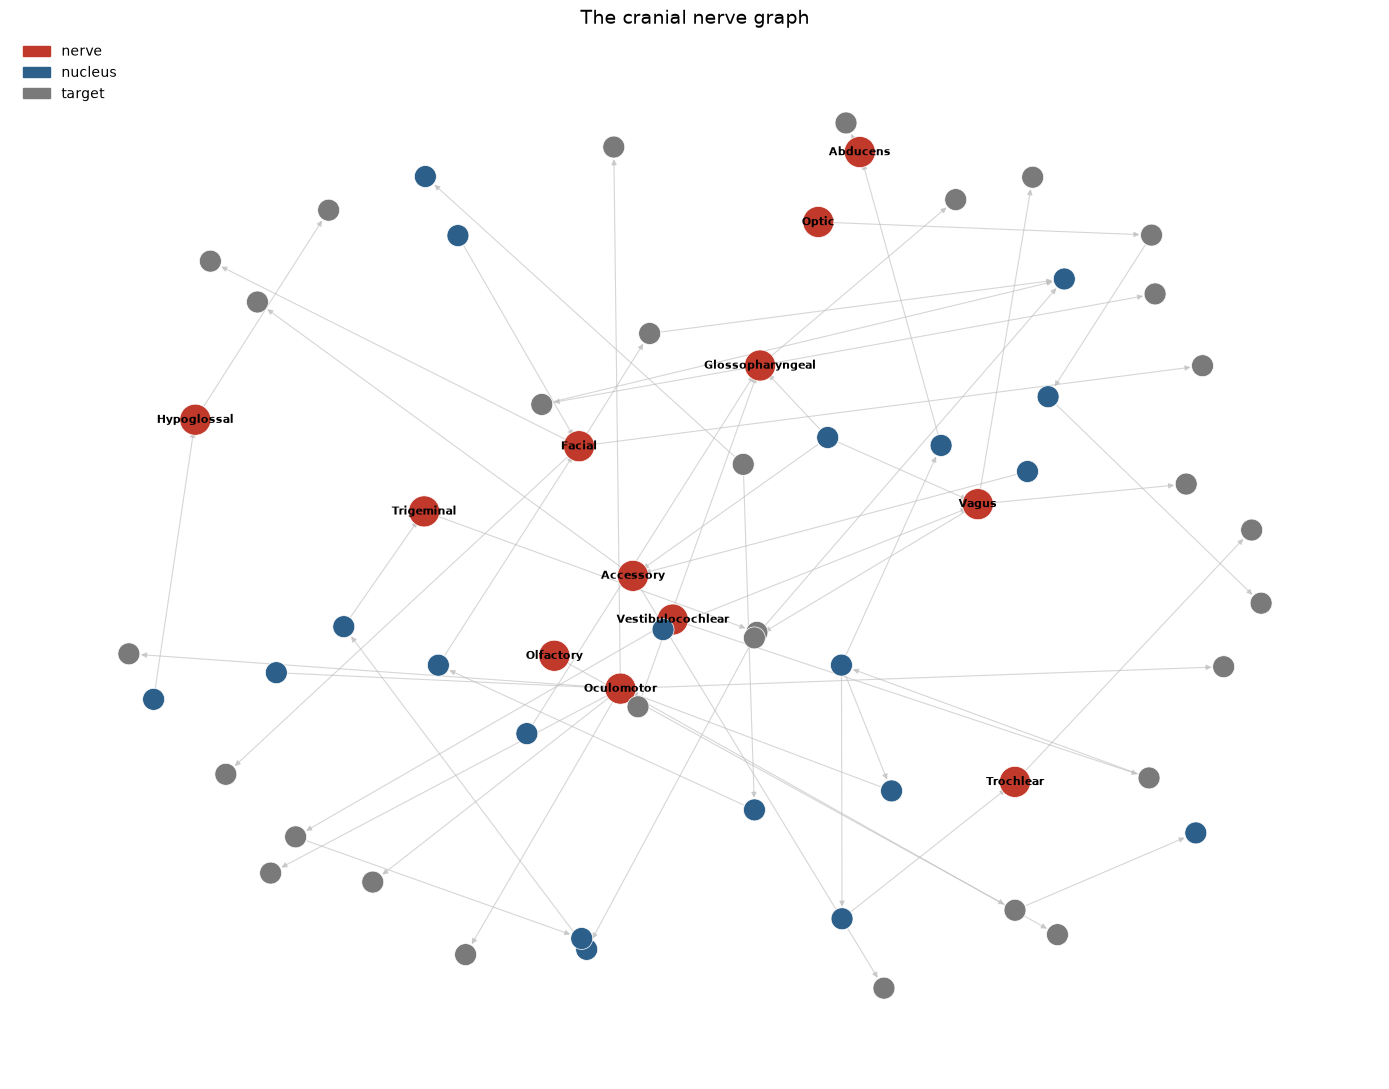

In [7]:
kind_colors = {"nerve": "#c0392b", "nucleus": "#2c5f8a", "target": "#7a7a7a"}
node_colors = [kind_colors[G.nodes[n]["kind"]] for n in G.nodes]
node_sizes = [500 if G.nodes[n]["kind"] == "nerve" else 250 for n in G.nodes]

pos = nx.spring_layout(G, seed=7, k=0.6)

fig, ax = plt.subplots(figsize=(14, 11))
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

nx.draw_networkx_edges(G, pos, ax=ax, edge_color="#bbbbbb", arrows=True,
                        arrowsize=8, width=0.8, alpha=0.6)
nx.draw_networkx_nodes(G, pos, ax=ax, node_color=node_colors, node_size=node_sizes,
                        edgecolors="white", linewidths=0.5)

nerve_labels = {n: G.nodes[n]["label"] for n in G.nodes if G.nodes[n]["kind"] == "nerve"}
nx.draw_networkx_labels(G, pos, labels=nerve_labels, ax=ax, font_size=8, font_weight="bold")

legend_handles = [mpatches.Patch(color=c, label=k) for k, c in kind_colors.items()]
ax.legend(handles=legend_handles, loc="upper left", frameon=False)
ax.set_title("The cranial nerve graph", fontsize=14)
ax.axis("off")
plt.tight_layout()
plt.savefig("cranial_nerve_graph.png", dpi=150, facecolor="white")
plt.show()

## Where this leaves things

The graph is built and it passes the basic sanity check — the nuclei I expected to be convergence points structurally are convergence points. That's a reasonable place to stop for Notebook 1.

### Things to try (Notebook 2 and beyond)

- Proper centrality measures (betweenness, closeness, eigenvector) rather than raw degree — betweenness in particular should be interesting for nucleus ambiguus and the solitary tract, since they sit *between* nerves and targets rather than just having many neighbours
- Shortest path between arbitrary pairs of nerves — e.g. how many hops from CN VIII to CN III via the VOR link, versus the "administrative" distance if that functional edge didn't exist
- Whether CN I and CN II genuinely look structurally different from III–XII given they don't route through a brainstem nucleus — my instinct says yes, worth checking
- Add the reflexes I left out of v1 (gag reflex, pupillary light reflex) and see if they change the centrality ranking
- Compare this hand-built, function-scale network against real connectome data at some point — different question (does a network built from what I know about *function* resemble anything about actual structural connectivity), but a natural extension once the graph theory toolkit is applied properly here